# Classifieur linéaire — CIFAR-10

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
def softmax(z):
    z_shift = z - np.max(z, axis=-1, keepdims=True)
    exp_z = np.exp(z_shift)
    return exp_z / np.sum(exp_z, axis=-1, keepdims=True)

def one_hot(y, num_classes=10):
    Y = np.zeros((len(y), num_classes), dtype=np.float32)
    Y[np.arange(len(y)), y] = 1.0
    return Y

def cross_entropy(probs, y):
    eps = 1e-12
    N = len(y)
    return -np.mean(np.log(probs[np.arange(N), y] + eps))

def forward(W, b, X):
    logits = X @ W + b
    return softmax(logits)

def backward(W, b, X, y, probs):
    N = len(y)
    dLogits = probs - one_hot(y, num_classes=W.shape[1])
    dLogits /= N
    dW = X.T @ dLogits
    db = dLogits.sum(axis=0)
    return dW, db

def accuracy(W, b, X, y):
    probs = forward(W, b, X)
    preds = np.argmax(probs, axis=1)
    return np.mean(preds == y)

def train(W, b, x_train, y_train, x_test, y_test, epochs=10, batch_size=256, lr=0.1, history=None):

    if history is None:
        history = {"train_loss": [], "test_acc": []}

    N = x_train.shape[0]
    n_batches = (N + batch_size - 1) // batch_size

    for epoch in range(epochs):
        idx = np.random.permutation(N)
        X_shuf = x_train[idx]
        y_shuf = y_train[idx]

        epoch_loss = 0.0
        for i in range(n_batches):
            xb = X_shuf[i*batch_size:(i+1)*batch_size]
            yb = y_shuf[i*batch_size:(i+1)*batch_size]

            probs = forward(W, b, xb)
            loss  = cross_entropy(probs, yb)
            epoch_loss += loss

            dW, db = backward(W, b, xb, yb, probs)
            W -= lr * dW
            b -= lr * db

        avg_loss = epoch_loss / n_batches
        test_acc = accuracy(W, b, x_test, y_test)

        history["train_loss"].append(avg_loss)
        history["test_acc"].append(test_acc)
        print(f"Epoch {epoch+1:>3}/{epochs} | loss: {avg_loss:.4f} | test acc: {test_acc:.4f}")

    return W, b, history

def plot_history(history, title="Training curves"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], marker="o")
    axes[0].set_title("Train loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[1].plot(history["test_acc"], marker="o", color="orange")
    axes[1].set_title("Test accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def show_prediction(W, b, X, y, idx=0):
    x = X[idx:idx+1]
    probs = forward(W, b, x)[0]
    pred  = np.argmax(probs)
    print(f"Vrai label : {y[idx]}  |  Prédiction : {pred}")
    plt.bar(range(10), probs)
    plt.xticks(range(10))
    plt.xlabel("Classe"); plt.ylabel("Probabilité")
    plt.title(f"Softmax — prédit={pred}, vrai={y[idx]}")
    plt.tight_layout()
    plt.show()


In [ ]:
import pickle, os

def unpickle(file):
    with open(file, "rb") as fo:
        d = pickle.load(fo, encoding="bytes")
    return d

CIFAR_PATH = "./data/CIFAR-10"

batches = [unpickle(os.path.join(CIFAR_PATH, f"data_batch_{i}")) for i in range(1, 6)]
test_b  =  unpickle(os.path.join(CIFAR_PATH, "test_batch"))

x_train_raw = np.concatenate([b[b'data'] for b in batches], axis=0)
y_train = np.concatenate([b[b'labels'] for b in batches]).astype(np.int64)
x_test_raw = test_b[b'data']
y_test = np.array(test_b[b'labels'], dtype=np.int64)

print("x_train_raw :", x_train_raw.shape, x_train_raw.dtype)
print("x_test_raw  :", x_test_raw.shape,  x_test_raw.dtype)


x_train_raw : (50000, 3072) uint8
x_test_raw  : (10000, 3072) uint8


C:\Users\thoma\AppData\Local\Temp\ipykernel_30584\1407218202.py:5: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(fo, encoding="bytes")


In [ ]:
def rgb_to_gray_batch(X_raw):
    N = X_raw.shape[0]

    R = X_raw[:, :1024].astype(np.float32) / 255.0
    G = X_raw[:, 1024:2048].astype(np.float32) / 255.0
    B = X_raw[:, 2048:].astype(np.float32) / 255.0
    return 0.299 * R + 0.587 * G + 0.114 * B

x_train_gray = rgb_to_gray_batch(x_train_raw)
x_test_gray  = rgb_to_gray_batch(x_test_raw)

mean_train = x_train_gray.mean()
std_train  = x_train_gray.std()

x_train = ((x_train_gray - mean_train) / std_train).astype(np.float32)
x_test  = ((x_test_gray  - mean_train) / std_train).astype(np.float32)

print("x_train :", x_train.shape, "| mean ≈", x_train.mean().round(4), "std ≈", x_train.std().round(4))
print("x_test  :", x_test.shape)


x_train : (50000, 1024) | mean≈ 0.0 std≈ 1.0
x_test  : (10000, 1024)


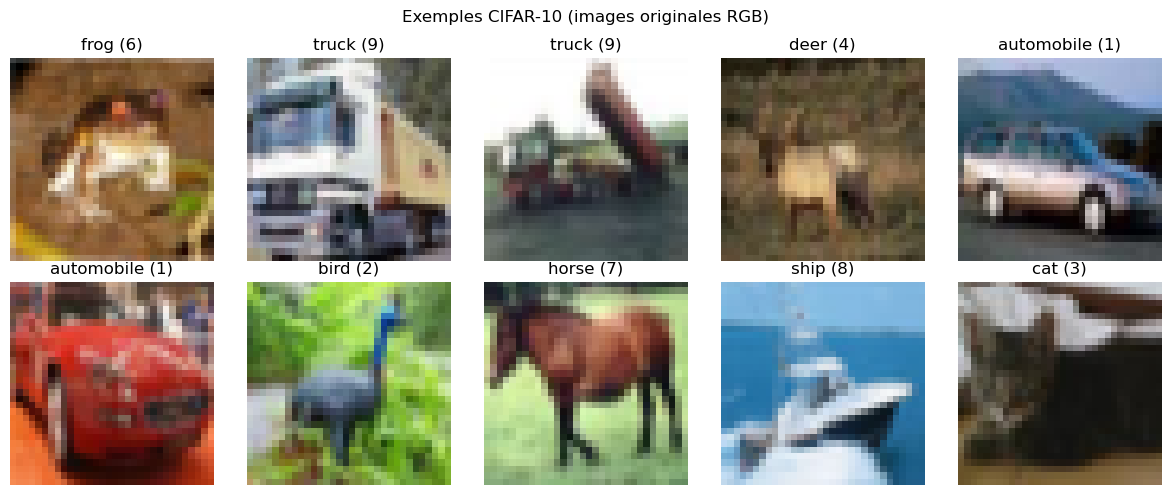

In [13]:
CLASSES = ["airplane","automobile","bird","cat","deer",
           "dog","frog","horse","ship","truck"]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, i in zip(axes.flat, range(10)):
    img_rgb = x_train_raw[i].reshape(3, 32, 32).transpose(1, 2, 0)
    ax.imshow(img_rgb)
    ax.set_title(f"{CLASSES[y_train[i]]} ({y_train[i]})")
    ax.axis("off")
plt.suptitle("Exemples CIFAR-10 (images originales RGB)")
plt.tight_layout()
plt.show()


In [ ]:
D, C = 1024, 10

rng = np.random.default_rng(42)
W = rng.normal(0, np.sqrt(1.0 / D), size=(D, C)).astype(np.float32)
b = np.zeros(C, dtype=np.float32)

history = {"train_loss": [], "test_acc": []}

W, b, history = train(W, b, x_train, y_train, x_test,  y_test, epochs = 50, batch_size = 128, lr = 0.005, history = history)


Epoch   1/50 | loss: 2.1679 | test acc: 0.2586
Epoch   2/50 | loss: 2.0804 | test acc: 0.2720
Epoch   3/50 | loss: 2.0584 | test acc: 0.2889
Epoch   4/50 | loss: 2.0443 | test acc: 0.2910
Epoch   5/50 | loss: 2.0334 | test acc: 0.2882
Epoch   6/50 | loss: 2.0260 | test acc: 0.2833
Epoch   7/50 | loss: 2.0194 | test acc: 0.2959
Epoch   8/50 | loss: 2.0144 | test acc: 0.2916
Epoch   9/50 | loss: 2.0100 | test acc: 0.2962
Epoch  10/50 | loss: 2.0058 | test acc: 0.2958
Epoch  11/50 | loss: 2.0023 | test acc: 0.2961
Epoch  12/50 | loss: 1.9992 | test acc: 0.2879
Epoch  13/50 | loss: 1.9965 | test acc: 0.2933
Epoch  14/50 | loss: 1.9942 | test acc: 0.2950
Epoch  15/50 | loss: 1.9922 | test acc: 0.2918
Epoch  16/50 | loss: 1.9903 | test acc: 0.2965
Epoch  17/50 | loss: 1.9882 | test acc: 0.2956
Epoch  18/50 | loss: 1.9872 | test acc: 0.2960
Epoch  19/50 | loss: 1.9856 | test acc: 0.2950
Epoch  20/50 | loss: 1.9842 | test acc: 0.2955
Epoch  21/50 | loss: 1.9823 | test acc: 0.2872
Epoch  22/50 

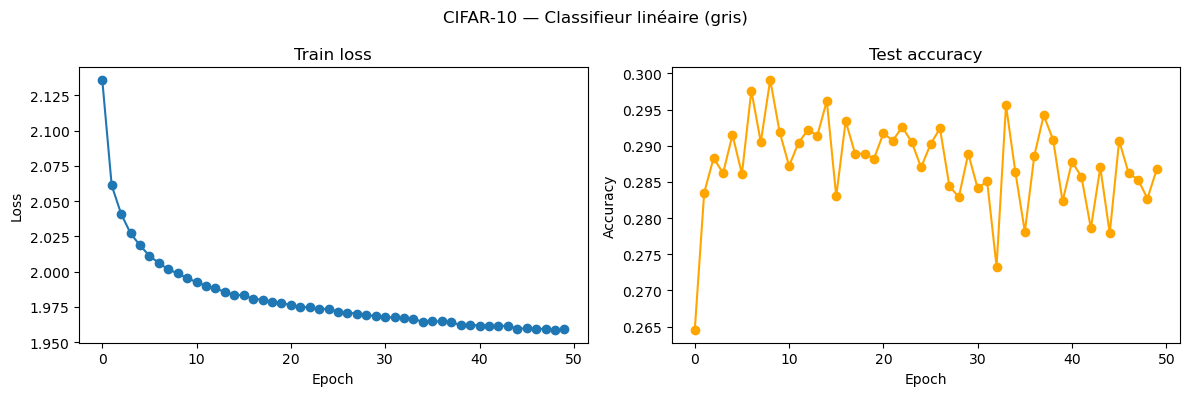

In [15]:
plot_history(history, title="CIFAR-10 — Classifieur linéaire (gris)")


In [ ]:
final_acc = accuracy(W, b, x_test, y_test)
print(f"Accuracy finale sur le test set : {final_acc:.4f}  ({final_acc*100:.2f} %)")

Accuracy finale sur le test set : 0.2868  (28.68 %)


Vrai label : 3  |  Prédiction : 6


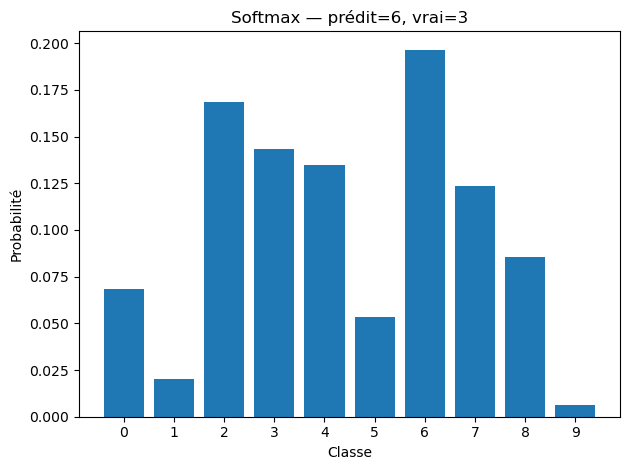

In [ ]:
show_prediction(W, b, x_test, y_test, idx=0)